# LIN340 — Preprocessing, Fine-tuning & Evaluation

Run all cells top to bottom. The notebook reads the novels, generates the data files, fine-tunes both models, and prints the evaluation results.

## 1. Colab Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
%cd /content/drive/MyDrive/LIN340Project
print('Working directory:', os.getcwd())
print('Files:', os.listdir('.'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/LIN340Project
Working directory: /content/drive/MyDrive/LIN340Project
Files: ['q.txt', 'guerra_agli_umani.txt', 'data', '__pycache__', 'checkpoints', 'results', 'preprocessing_code.ipynb', 'evaluate.py', 'train.py', 'config.py', 'train_eval.ipynb']


In [2]:
!pip install -q transformers peft datasets bert-score rouge-score nltk accelerate sentencepiece

## 2. Preprocessing

Reads the two novels, segments into sentences, applies syntactic bracket tagging, splits 80/10/10, and writes the `data/` files.

In [3]:
!pip install stanza

In [4]:
import re, os, random, string, stanza

stanza.download('it', processors='tokenize,pos,lemma,constituency', verbose=False)
nlp_stanza = stanza.Pipeline('it', processors='tokenize,pos,lemma,constituency', verbose=False)

EXTRA_PUNCT = '\u00ab\u00bb\u201c\u201d\u2018\u2019\u2013\u2014\u2026'
ALL_PUNCT = string.punctuation + EXTRA_PUNCT

def remove_punctuation(text):
    return text.translate(str.maketrans('', '', ALL_PUNCT))

def read_novel(path):
    with open(path, encoding='latin-1') as f:
        txt = f.read()
    txt = re.sub(r'\n', ' ', txt)
    txt = re.sub(r'\s+', ' ', txt)
    return txt.lower()

PHRASE_TAGS = {'NP': 'NP', 'VP': 'VP', 'PP': 'PP', 'ADJP': 'AP', 'ADVP': 'ADVP'}

def render_tree(node, word_iter):
    if node.is_leaf():
        word = next(word_iter, None)
        if word is None:
            return ''
        return remove_punctuation(word.lemma)
    label = node.label
    parts = [p for p in [render_tree(c, word_iter) for c in node.children] if p.strip()]
    children_text = ' '.join(parts)
    if not children_text.strip():
        return ''
    if label in PHRASE_TAGS:
        tag = PHRASE_TAGS[label]
        return f'[{tag}_START] {children_text} [{tag}_END]'
    return children_text

def process_text(text, stanza_nlp, chunk_size=50000):
    raw_sents, tagged_sents = [], []
    i = 0
    while i < len(text):
        chunk = text[i:i + chunk_size]
        if i + chunk_size < len(text):
            last_space = chunk.rfind(' ')
            if last_space > 0:
                chunk = chunk[:last_space]
        doc = stanza_nlp(chunk)
        for sent in doc.sentences:
            lemmas = [l for l in [remove_punctuation(w.lemma) for w in sent.words] if l.strip()]
            raw = ' '.join(lemmas).strip()
            if len(raw) <= 10:
                continue
            raw_sents.append(raw)
            tagged = re.sub(r'\s+', ' ', render_tree(sent.constituency, iter(sent.words))).strip()
            tagged_sents.append(tagged if tagged else raw)
        i += len(chunk)
    return raw_sents, tagged_sents

print('Reading novels...')
txt  = read_novel('q.txt')
txt2 = read_novel('guerra_agli_umani.txt')
print(f'q.txt: {len(txt)} chars')
print(f'guerra: {len(txt2)} chars')

print('Processing q...')
q_raw, q_tagged = process_text(txt, nlp_stanza)
print(f'  {len(q_raw)} sentences')

print('Processing guerra agli umani...')
g_raw, g_tagged = process_text(txt2, nlp_stanza)
print(f'  {len(g_raw)} sentences')

combined = list(zip(q_raw + g_raw, q_tagged + g_tagged))
random.seed(42)
random.shuffle(combined)
all_raw, all_tagged = zip(*combined)
all_raw, all_tagged = list(all_raw), list(all_tagged)
print(f'Total: {len(all_raw)} sentence pairs')

Reading novels...
q.txt: 1111963 chars
guerra: 526633 chars
Processing q...
  12538 sentences
Processing guerra agli umani...
  8402 sentences
Total: 20940 sentence pairs


In [5]:
n = len(all_raw)
train_raw    = all_raw   [:int(n * 0.8)]
val_raw      = all_raw   [int(n * 0.8):int(n * 0.9)]
test_raw     = all_raw   [int(n * 0.9):]
train_tagged = all_tagged[:int(n * 0.8)]
val_tagged   = all_tagged[int(n * 0.8):int(n * 0.9)]
test_tagged  = all_tagged[int(n * 0.9):]
print(f'Train: {len(train_raw)}, Val: {len(val_raw)}, Test: {len(test_raw)}')

os.makedirs('data', exist_ok=True)

for name, sents in [('raw_train', train_raw), ('raw_val', val_raw), ('raw_test', test_raw)]:
    with open(f'data/{name}.txt', 'w', encoding='utf-8') as f:
        f.write('\n'.join(sents))
    print(f'Wrote data/{name}.txt')

for name, sents in [('tagged_train', train_tagged), ('tagged_val', val_tagged), ('tagged_test', test_tagged)]:
    with open(f'data/{name}.txt', 'w', encoding='utf-8') as f:
        f.write('\n'.join(sents))
    print(f'Wrote data/{name}.txt')

# Use longer sentences so prompts give the model enough context to avoid
# degenerate repetition. Split at 2/3 so the prompt is substantial but
# there is still a meaningful reference to score against.
pairs = []
for sent in test_raw:
    words = sent.split()
    if len(words) < 15:
        continue
    cut = int(len(words) * 2 / 3)
    pairs.append(' '.join(words[:cut]))
    pairs.append(' '.join(words[cut:]))
    if len(pairs) >= 40:
        break

if len(pairs) < 10:
    print(f'Warning: only {len(pairs)//2} prompt pairs found — consider lowering the min length threshold')

with open('data/eval_prompts.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(pairs))
print(f'Wrote data/eval_prompts.txt ({len(pairs)//2} pairs)')

Train: 16752, Val: 2094, Test: 2094
Wrote data/raw_train.txt
Wrote data/raw_val.txt
Wrote data/raw_test.txt
Wrote data/tagged_train.txt
Wrote data/tagged_val.txt
Wrote data/tagged_test.txt
Wrote data/eval_prompts.txt (20 pairs)


## 3. Train — Raw Model

In [6]:
!python train.py --mode raw

Loading weights: 100% 148/148 [00:00<00:00, 1411.40it/s, Materializing param=transformer.wte.weight]
GPT2LMHeadModel LOAD REPORT from: GroNLP/gpt2-small-italian
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 
transformer.h.{0...11}.attn.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(
trainable params: 1,622,016 || all params: 110,505,216 || trainable%: 1.4678
Tokenising data...
Train blocks: 1162, Val blocks: 144
  0% 0/370 [00:00<?, ?it/s]`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.
 10% 37/370 [00:0

## 4. Train — Tagged Model

In [7]:
!python train.py --mode tagged

Loading weights: 100% 148/148 [00:00<00:00, 1567.17it/s, Materializing param=transformer.wte.weight]
GPT2LMHeadModel LOAD REPORT from: GroNLP/gpt2-small-italian
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.bias        | UNEXPECTED |  | 
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`
Added 10 special tokens.
/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(
tra

## 5. Evaluate Both Models

In [8]:
!python evaluate.py


--- RAW ---
Loading weights: 100% 148/148 [00:00<00:00, 1229.44it/s, Materializing param=transformer.wte.weight]
GPT2LMHeadModel LOAD REPORT from: GroNLP/gpt2-small-italian
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.bias        | UNEXPECTED |  | 
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.
Perplexity: 172.64
config.json: 100% 433/433 [00:00<00:00, 1.50MB/s]
tokenizer_config.json: 100% 59.0/59.0 [00:00<00:00, 394kB/s]
vocab.txt: 235kB [00:00, 74.6MB/s]
model.safetensors: 100% 442M/442M [00:02<00:00, 169MB/s] 
Loading weights: 100% 199/199 [00:00<00:00, 903.11it/s, Materializing param=pooler.dense.weight]
BertModel LOAD REPORT from: dbmdz/bert-base

## 6. View Results

In [9]:
import json

with open('results/eval_results.json') as f:
    results = json.load(f)

metrics = ['perplexity', 'bleu_1', 'bleu_2', 'bleu_3', 'bleu_4',
           'rouge1', 'rouge2', 'rougeL',
           'bertscore_p', 'bertscore_r', 'bertscore_f1']

rows = results['results']
print(f"{'Metric':<22}" + ''.join(f"{r['mode'].upper():>14}" for r in rows))
print('-' * (22 + 14 * len(rows)))
for m in metrics:
    print(f'{m:<22}' + ''.join(f"{r[m]:>14.4f}" for r in rows))

Metric                           RAW        TAGGED
--------------------------------------------------
perplexity                  172.6382      174.5812
bleu_1                        0.0294        0.0305
bleu_2                        0.0152        0.0144
bleu_3                        0.0071        0.0076
bleu_4                        0.0044        0.0046
rouge1                        0.0537        0.0557
rouge2                        0.0142        0.0126
rougeL                        0.0519        0.0503
bertscore_p                   0.5042        0.5034
bertscore_r                   0.5544        0.5595
bertscore_f1                  0.5275        0.5295


## 7. Plots

/tmp/ipykernel_8586/1211809825.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([m.upper() for m in modes])


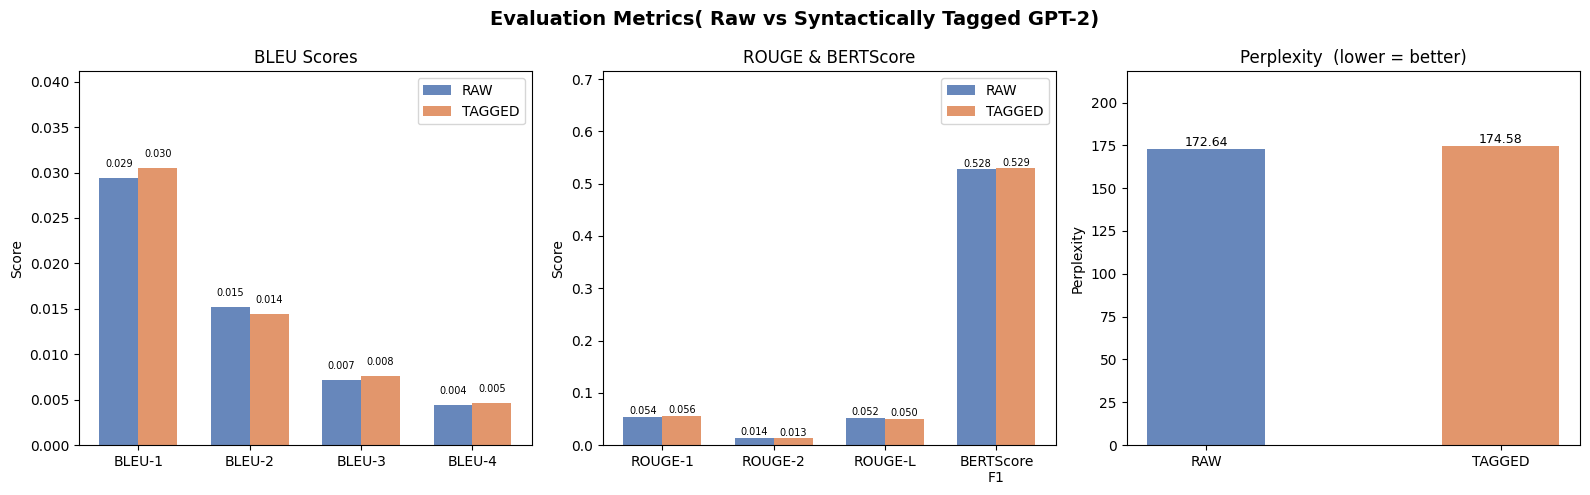

Saved → results/metrics_comparison.png


In [10]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open('results/eval_results.json') as f:
    data = json.load(f)

res   = {r['mode']: r for r in data['results']}
modes = [m for m in ['raw', 'tagged'] if m in res]
colors = {'raw': '#4C72B0', 'tagged': '#DD8452'}
width  = 0.35

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Evaluation Metrics( Raw vs Syntactically Tagged GPT-2)', fontsize=14, fontweight='bold')

ax = axes[0]
bleu_keys   = ['bleu_1', 'bleu_2', 'bleu_3', 'bleu_4']
bleu_labels = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4']
x = np.arange(len(bleu_keys))
for i, mode in enumerate(modes):
    vals = [res[mode][k] for k in bleu_keys]
    bars = ax.bar(x + (i - 0.5) * width, vals, width,
                  label=mode.upper(), color=colors[mode], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7)
ax.set_title('BLEU Scores')
ax.set_xticks(x)
ax.set_xticklabels(bleu_labels)
ax.set_ylabel('Score')
ax.set_ylim(0, max(res[m][k] for m in modes for k in bleu_keys) * 1.35)
ax.legend()

ax = axes[1]
other_keys   = ['rouge1', 'rouge2', 'rougeL', 'bertscore_f1']
other_labels = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BERTScore\nF1']
x = np.arange(len(other_keys))
for i, mode in enumerate(modes):
    vals = [res[mode][k] for k in other_keys]
    bars = ax.bar(x + (i - 0.5) * width, vals, width,
                  label=mode.upper(), color=colors[mode], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7)
ax.set_title('ROUGE & BERTScore')
ax.set_xticks(x)
ax.set_xticklabels(other_labels)
ax.set_ylabel('Score')
ax.set_ylim(0, max(res[m][k] for m in modes for k in other_keys) * 1.35)
ax.legend()

ax = axes[2]
ppls = [res[m]['perplexity'] for m in modes]
bars = ax.bar(modes, ppls, color=[colors[m] for m in modes], alpha=0.85, width=0.4)
for bar, v in zip(bars, ppls):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{v:.2f}', ha='center', va='bottom', fontsize=9)
ax.set_title('Perplexity  (lower = better)')
ax.set_ylabel('Perplexity')
ax.set_xticklabels([m.upper() for m in modes])
ax.set_ylim(0, max(ppls) * 1.25)

plt.tight_layout()
os.makedirs('results', exist_ok=True)
plt.savefig('results/metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/metrics_comparison.png')

## 8. Example Outputs

In [11]:
import json, textwrap

with open('results/eval_results.json') as f:
    data = json.load(f)

hyps = data['hypotheses']  # {'raw': [...], 'tagged': [...]}

with open('data/eval_prompts.txt', encoding='utf-8') as f:
    lines = [l.strip() for l in f if l.strip()]
prompts    = lines[0::2]
references = lines[1::2]

N_SHOW = 5
W = 88

print('=' * W)
print(f'{"EXAMPLE OUTPUTS — RAW vs TAGGED MODEL":^{W}}')
print('=' * W)

for i in range(min(N_SHOW, len(prompts))):
    print(f'\n  Example {i + 1}')
    print(f'  {"PROMPT":<11}: {prompts[i]}')
    print(f'  {"REFERENCE":<11}: {references[i]}')
    for mode in ('raw', 'tagged'):
        if mode not in hyps:
            continue
        label = mode.upper()
        text  = hyps[mode][i] if hyps[mode][i].strip() else '(empty)'
        first_line  = f'  {label:<11}: '
        subsequent  = ' ' * len(first_line)
        wrapped = textwrap.fill(text, width=W,
                                initial_indent=first_line,
                                subsequent_indent=subsequent)
        print(wrapped)
    print('-' * W)

                         EXAMPLE OUTPUTS — RAW vs TAGGED MODEL                          

  Example 1
  PROMPT     : qualcosa di distante che si avvicinare veloce trascinare da uno
  REFERENCE  : vento che spazzare il memoria
  RAW        :  angolo di il terra a il suo fianco e a il altro in mezzo a il finestra
               di il salotto di il casa di il signore di il città di il paese di il
               quale si avere conoscere il nome e il nome di il vescovo di il diocesi di
               il provincia di il comune di il luogo di nascita e di il sede di il
               cattedrale di il chiesa di il santo patrono di il popolo di il nostro
               città e di quello di il nazione di il regno di il figlio di il re di il
               reame
  TAGGED     :  angolo di il terra a il suo fianco e a il finestra di il salotto di il
               casa di il signore di il città di il quale si avere parlare il giorno
               prima di il morte di il padre di il figlio di il re